# Ensemble Models

- Author: Sydney Sailors
- Date: 2026-07
- Dataset: Medical Cost Prediction
- Target: annual_medical_cost

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This project uses the Medical Cost Prediction dataset.
We choose to predict the target `annual_medical_cost`.
This target is a **continuous numerical value**, so we have a 
supervised machine learning regression problem. 


## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [25]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 16:48:19 | INFO | M05 | === RUN START ===
2026-08-02 16:48:19 | INFO | M05 | project=M05
2026-08-02 16:48:19 | INFO | M05 | repo_dir=ml-05-ensembles
2026-08-02 16:48:19 | INFO | M05 | python=3.14.5
2026-08-02 16:48:19 | INFO | M05 | os=Darwin 20.6.0
2026-08-02 16:48:19 | INFO | M05 | shell=zsh
2026-08-02 16:48:19 | INFO | M05 | cwd=notebooks
2026-08-02 16:48:19 | INFO | M05 | github_actions=False
2026-08-02 16:48:19 | INFO | M05 | Confirming installation:
2026-08-02 16:48:19 | INFO | M05 |   python:       3.14.5
2026-08-02 16:48:19 | INFO | M05 |   pandas:       3.0.5
2026-08-02 16:48:19 | INFO | M05 |   numpy:        2.5.1
2026-08-02 16:48:19 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-02 16:48:19 | INFO | M05 |   seaborn:      0.13.2
2026-08-02 16:48:19 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [26]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# Change to explore a different dataset.
DATASET_NAME: Final[str] = "Medical Cost Prediction"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv("../data/raw/medical_cost_prediction_dataset.csv")
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

TARGET_COL: Final[str] = "annual_medical_cost"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "previous_year_cost",
    "age",
    "bmi",
    "doctor_visits_per_year",
    "hospital_admissions",
    "medication_count",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")

2026-08-02 16:48:19 | INFO | M05 | Loading dataset: Medical Cost Prediction
2026-08-02 16:48:19 | INFO | M05 | Loaded: 5000 rows (instances), 20 columns
2026-08-02 16:48:19 | INFO | M05 | Original rows: 5000
2026-08-02 16:48:19 | INFO | M05 | Model rows:    5000


## Section 3. Split into Train and Test

We hold out a test set the model never sees during training. 
This allows us to evaluate how well each model predicts 
medical costs for new observations. The same train/test split
is used for every model so their performance can be compared fairly. 

In [27]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into train and test sets.

WHY: Scoring on held-out data provides an estimate
of how well the models perform on new observations.
The same split is used for every model for a fair comparison.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 16:48:19 | INFO | M05 | Train instances: 4000
2026-08-02 16:48:19 | INFO | M05 | Test instances: 1000


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [28]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingRegressor(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-08-02 16:48:19 | INFO | M05 | Fitting single tree + two ensembles
2026-08-02 16:48:19 | DEBUG | M05 |   fitted: single_tree


2026-08-02 16:48:22 | DEBUG | M05 |   fitted: random_forest
2026-08-02 16:48:22 | DEBUG | M05 |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-02 16:48:23 | INFO | M05 | single_tree: MAE=$5,139.61, RMSE=$6,779.77, R2=0.058
2026-08-02 16:48:23 | INFO | M05 | random_forest: MAE=$5,266.71, RMSE=$6,817.12, R2=0.047
2026-08-02 16:48:23 | INFO | M05 | gradient_boosting: MAE=$5,031.15, RMSE=$6,616.95, R2=0.102


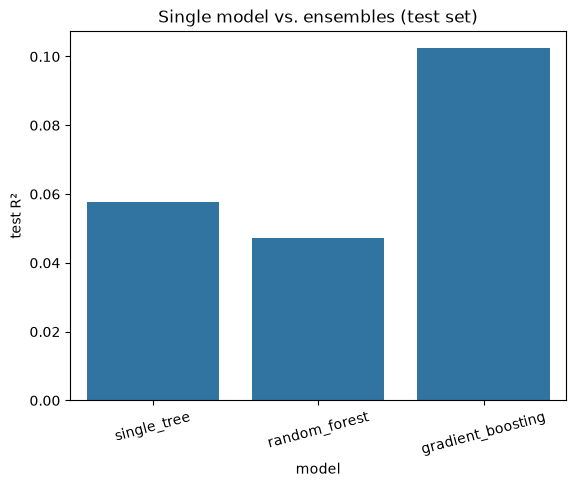

2026-08-02 16:48:23 | INFO | M05 | Best model: gradient_boosting with R2 = 0.102


In [29]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.

Code only reports numbers.

Whether an ensemble's gain
is large enough to justify its cost
depends on this specific problem,
and requires analyst judgment.
"""

# score each model on the held-out test set
pred_single_tree = modelA.predict(X_test)
pred_random_forest = modelB.predict(X_test)
pred_gradient_boosting = modelC.predict(X_test)

results = {
    "single_tree": {
        "MAE": mean_absolute_error(y_test, pred_single_tree),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_single_tree)),
        "R2": r2_score(y_test, pred_single_tree),
    },
    "random_forest": {
        "MAE": mean_absolute_error(y_test, pred_random_forest),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_random_forest)),
        "R2": r2_score(y_test, pred_random_forest),
    },
    "gradient_boosting": {
        "MAE": mean_absolute_error(y_test, pred_gradient_boosting),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_gradient_boosting)),
        "R2": r2_score(y_test, pred_gradient_boosting),
    },
}

for model_name, metrics in results.items():
    LOG.info(
        f"{model_name}: "
        f"MAE=${metrics['MAE']:,.2f}, "
        f"RMSE=${metrics['RMSE']:,.2f}, "
        f"R2={metrics['R2']:.3f}"
    )

# start a new figure
r2_scores = {
    "single_tree": results["single_tree"]["R2"],
    "random_forest": results["random_forest"]["R2"],
    "gradient_boosting": results["gradient_boosting"]["R2"],
}

plt.figure()
sns.barplot(x=list(r2_scores.keys()), y=list(r2_scores.values()))

plt.xlabel("model")
plt.ylabel("test R²")
plt.title("Single model vs. ensembles (test set)")
plt.xticks(rotation=15)

plt.show()

# find the best model by name using the highest R2.
best: str = max(r2_scores, key=r2_scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with R2 = {r2_scores[best]:.3f}")

## Section 6. Which Features Did the Forest Rely On?

2026-08-02 16:48:23 | INFO | M05 | Random forest feature importances (high to low):
2026-08-02 16:48:23 | INFO | M05 |   previous_year_cost   0.255
2026-08-02 16:48:23 | INFO | M05 |   bmi                  0.217
2026-08-02 16:48:23 | INFO | M05 |   age                  0.191
2026-08-02 16:48:23 | INFO | M05 |   hospital_admissions  0.140
2026-08-02 16:48:23 | INFO | M05 |   doctor_visits_per_year 0.105
2026-08-02 16:48:23 | INFO | M05 |   medication_count     0.092


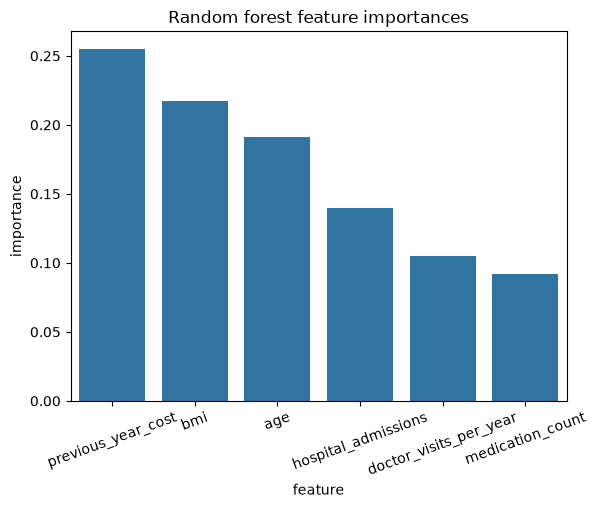

In [30]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

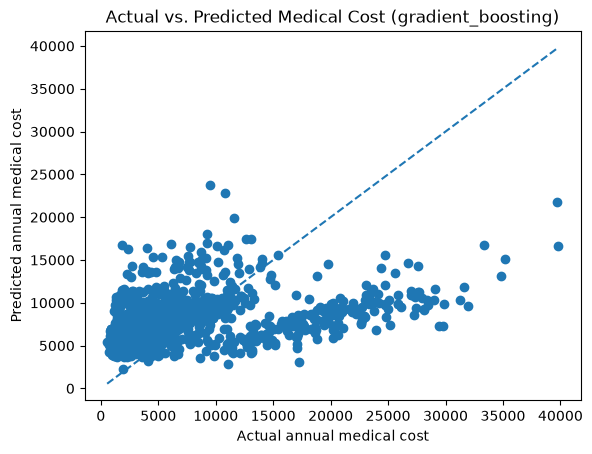

In [31]:
best_predictions = {
    "single_tree": pred_single_tree,
    "random_forest": pred_random_forest,
    "gradient_boosting": pred_gradient_boosting,
}

best_predictions_values = best_predictions[best]

plt.figure()
plt.scatter(y_test, best_predictions_values)

min_value = min(y_test.min(), best_predictions_values.min())
max_value = max(y_test.max(), best_predictions_values.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual annual medical cost")
plt.ylabel("Predicted annual medical cost")
plt.title(f"Actual vs. Predicted Medical Cost ({best})")

plt.show()

In [32]:
results_df = pd.DataFrame(results).T

print(results_df)

                           MAE         RMSE        R2
single_tree        5139.608070  6779.772637  0.057633
random_forest      5266.710233  6817.120707  0.047222
gradient_boosting  5031.153483  6616.952198  0.102353


## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [33]:
# === Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (regression)")
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
LOG.info("========================")

2026-08-02 16:48:24 | INFO | M05 | ========================
2026-08-02 16:48:24 | INFO | M05 | SUMMARY
2026-08-02 16:48:24 | INFO | M05 | ========================
2026-08-02 16:48:24 | INFO | M05 | Dataset: Medical Cost Prediction   Target: annual_medical_cost (regression)
2026-08-02 16:48:24 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting
2026-08-02 16:48:24 | INFO | M05 | ========================


## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
